# Stage 2 MRD Figure 3 Sharedness Visualization Suite

This notebook analyzes the completed multi-objective Stage 2 supervised-probe run for the MRD old-34 broad screen. The focus is the current multi-objective output, not the earlier quick L2 GroupKFold triage result.

Scientific question: which Stage 0/Stage 1 representations expose malignant-vs-non-malignant programs that transfer across patients, and which look patient-specific or subgroup-specific?

Stage 2 objectives remain separated:

- `discovery_full_cohort_fit`: apparent full-cohort discovery model for biological triage and coefficient paths.
- `sharedness_leave_patient_out`: LOPO transfer test for heldout-patient generalization.
- `patient_specific`: within-patient apparent model on the same Stage 1 basis.

Critical rule: factor coefficient comparisons are only interpretable within an identical Stage 1 basis. Aggregate metrics can be compared across representations; factor identities cannot.


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError as exc:
    plt = None
    sns = None
    warnings.warn(f'Plotting dependencies are missing in this kernel: {exc}')

def _find_repo_root(start: Path) -> Path:
    """Locate mds_project root whether the kernel cwd is repo root, notebooks/, or experiment/."""
    marker = Path('sc_classification/scripts/comprehensive_run/stage2_sharedness_plotting.py')
    for base in [start, *start.parents]:
        if (base / marker).is_file():
            return base
    raise FileNotFoundError(
        f'Could not find repo root (missing {marker}). '
        f'Start Jupyter from mds_project or open this notebook from its path under sc_classification/scripts/comprehensive_run/notebooks/. '
        f'Current working directory: {start.resolve()}'
    )


NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = _find_repo_root(NOTEBOOK_DIR)
HELPER_DIR = REPO_ROOT / 'sc_classification/scripts/comprehensive_run'
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))
print(f'REPO_ROOT={REPO_ROOT}')
print(f'HELPER_DIR={HELPER_DIR}')

import stage2_sharedness_plotting as _stage2_sharedness_plotting
importlib.reload(_stage2_sharedness_plotting)

from stage2_sharedness_plotting import (
    BASIS_MATCH_COLUMNS,
    build_artifact_inventory,
    choose_interpretable_row_near_best,
    load_stage2_artifacts,
    plot_discovery_vs_lopo_sharedness,
    plot_lopo_coefficient_stability,
    plot_lopo_patient_heatmap,
    plot_patient_specific_factor_usage,
    print_artifact_summary,
    resolve_col,
    safe_filename,
    select_regularization_rows,
    select_representations_for_coefficient_heatmaps,
    write_markdown_report,
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 160)
if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')


REPO_ROOT=/home/minhang/mds_project
HELPER_DIR=/home/minhang/mds_project/sc_classification/scripts/comprehensive_run


## Parameters

Only the experiment directory is fixed. Output paths are inferred below.


In [2]:
EXPERIMENT_DIR = REPO_ROOT / 'sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093'
OUTPUT_DIR = EXPERIMENT_DIR / 'analysis/figures/stage2_figure3_sharedness'
TABLE_DIR = EXPERIMENT_DIR / 'analysis/scorecards/stage2_figure3_sharedness'

SELECTION_MODE = 'max_metric'
SELECTION_METRIC = 'stage2_auprc'
PENALTY_PRIORITY = ('elasticnet', 'l1', 'l2')

N_TOP_SHARED = 5
N_TOP_PATIENT_SPECIFIC_GAP = 5
N_FORCE_INCLUDE_PATTERNS = ['interferon', 'ifn', 'cytokine', 'tnfa', 'nfkb', 'antigen', 'mhc', 'full_34', 'core', 'hvg']

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIR, OUTPUT_DIR, TABLE_DIR


(PosixPath('/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093'),
 PosixPath('/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness'),
 PosixPath('/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness'))

## Part 1: Artifact Audit

The audit recursively searches the experiment directory for Stage 2 multi-objective outputs and records likely roles by filename plus column signatures. Optional artifacts are allowed to be absent; downstream sections check availability before plotting.


In [3]:
artifacts = load_stage2_artifacts(EXPERIMENT_DIR)
inventory = artifacts['artifact_inventory']
inventory_path = TABLE_DIR / 'artifact_inventory.csv'
inventory.to_csv(inventory_path, index=False)
print(f'Wrote {inventory_path} with {len(inventory)} candidate artifacts')
print_artifact_summary(inventory)

display(
    inventory.sort_values(['candidate_role', 'path'])
    .groupby('candidate_role', as_index=False)
    .head(8)
)


Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/artifact_inventory.csv with 3296 candidate artifacts
Artifact roles found:
  - cell_metadata: 26
  - cell_prediction_fit_metadata: 27
  - cell_prediction_matrix: 36
  - discovery_coefficients: 16
  - discovery_metrics: 18
  - lopo_aggregate_metrics: 19
  - lopo_by_patient_metrics: 30
  - patient_specific_coefficients: 12
  - patient_specific_metrics: 15
  - stage1_loadings: 736
  - stage1_metadata: 737
  - unknown: 1624

Plots available now:
  - Fig 3A discovery-vs-LOPO scatter
  - Fig 3B LOPO per-patient heatmap
  - Fig 3D discovery-vs-patient-specific factor usage

Missing/optional inputs:
  - Fig 3C requires LOPO fold coefficient paths


,artifact_name,path,exists,file_type,n_rows_if_csv,n_cols_if_csv,candidate_role,notes
1627,cell_metadata.csv.gz,stage2_supervised/multiobjective/discovery_full_cohort/cell_metadata.csv.gz,True,.csv.gz,60118.0,14.0,cell_metadata,
1631,cell_metadata.csv.gz,stage2_supervised/multiobjective/patient_specific/cell_metadata.csv.gz,True,.csv.gz,60118.0,14.0,cell_metadata,
1635,cell_metadata.csv.gz,stage2_supervised/multiobjective/runs/20260526_stage2_discovery_gpu8/merged/discovery_full_cohort/cell_metadata.csv.gz,True,.csv.gz,60118.0,14.0,cell_metadata,
1640,cell_metadata.csv.gz,stage2_supervised/multiobjective/runs/20260526_stage2_discovery_gpu8/shards/shard_000_of_008/discovery_full_cohort/cell_metadata.csv.gz,True,.csv.gz,60118.0,14.0,cell_metadata,
1645,cell_metadata.csv.gz,stage2_supervised/multiobjective/runs/20260526_stage2_discovery_gpu8/shards/shard_001_of_008/discovery_full_cohort/cell_metadata.csv.gz,True,.csv.gz,60118.0,14.0,cell_metadata,
...,...,...,...,...,...,...,...,...
3,fig3A_discovery_vs_lopo_sharedness_interactive.html,analysis/figures/stage2_figure3_sharedness/fig3A_discovery_vs_lopo_sharedness_interactive.html,True,.html,NaN,NaN,unknown,
4,fig3B_lopo_per_patient_auprc_heatmap.pdf,analysis/figures/stage2_figure3_sharedness/fig3B_lopo_per_patient_auprc_heatmap.pdf,True,.pdf,NaN,NaN,unknown,
5,fig3B_lopo_per_patient_auprc_heatmap.png,analysis/figures/stage2_figure3_sharedness/fig3B_lopo_per_patient_auprc_heatmap.png,True,.png,NaN,NaN,unknown,
6,fig3D_patient_specific_factor_usage__core_only_dr_pca_40_42.pdf,analysis/figures/stage2_figure3_sharedness/fig3D_patient_specific_factor_usage__core_only_dr_pca_40_42.pdf,True,.pdf,NaN,NaN,unknown,


### Completed Run Check

The expected multi-objective outputs are present when discovery, LOPO, and patient-specific canonical scorecards are all loaded. The run also has launcher and merge manifests under `stage2_supervised/multiobjective/runs/`, which record completed sharded jobs and row counts.


In [4]:
for key in ['discovery_metrics', 'lopo_metrics', 'lopo_by_patient', 'discovery_coef', 'patient_specific_metrics', 'patient_specific_coef', 'lopo_coef']:
    df = artifacts.get(key, pd.DataFrame())
    path = artifacts.get(f'{key}_path')
    print(f'{key:28s} rows={len(df):>8} path={path}')

manifest_paths = sorted((EXPERIMENT_DIR / 'stage2_supervised/multiobjective/runs').glob('20260526_stage2_*_gpu8/merged/merge_manifest.json'))
for manifest in manifest_paths:
    print(manifest.relative_to(EXPERIMENT_DIR))


discovery_metrics            rows=    2145 path=/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_discovery_full_cohort_scorecard.csv
lopo_metrics                 rows=    2145 path=/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_sharedness_lopo_scorecard.csv
lopo_by_patient              rows=   27885 path=/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/stage2_supervised/multiobjective/sharedness_lopo/by_heldout_patient.csv
discovery_coef               rows=   47775 path=/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/stage2_supervised/multiobjective/discovery_full_cohort/coefficient_paths.csv
patient_specific_metrics     rows=   19305 path=/home/minhang/mds_project/sc_classification/exp

## Part 2-4: Canonical Loading, IDs, and Biological Themes

Canonical dataframes include stable `representation_id` and `model_id` columns, `stage1_seed`, `patient_id` / `heldout_patient_id` aliases where applicable, `biological_theme`, and `short_panel_label`. Stage 1 score/loading paths are attached from the Stage 2 shortlist when available.


In [5]:
discovery_metrics = artifacts['discovery_metrics']
lopo_metrics = artifacts['lopo_metrics']
lopo_by_patient = artifacts['lopo_by_patient']
discovery_coef = artifacts['discovery_coef']
lopo_coef = artifacts['lopo_coef']
patient_specific_metrics = artifacts['patient_specific_metrics']
patient_specific_coef = artifacts['patient_specific_coef']
stage1_metadata = artifacts['stage1_metadata']

summary_rows = []
for name, df in [
    ('discovery_metrics', discovery_metrics),
    ('lopo_metrics', lopo_metrics),
    ('lopo_by_patient', lopo_by_patient),
    ('discovery_coef', discovery_coef),
    ('lopo_coef', lopo_coef),
    ('patient_specific_metrics', patient_specific_metrics),
    ('patient_specific_coef', patient_specific_coef),
    ('stage1_metadata', stage1_metadata),
]:
    summary_rows.append({
        'table': name,
        'rows': len(df),
        'columns': len(df.columns) if hasattr(df, 'columns') else 0,
        'representations': df['representation_id'].nunique() if isinstance(df, pd.DataFrame) and 'representation_id' in df.columns else np.nan,
    })
summary = pd.DataFrame(summary_rows)
display(summary)
summary.to_csv(TABLE_DIR / 'stage2_fig3_loaded_artifact_summary.csv', index=False)


,table,rows,columns,representations
0,discovery_metrics,2145,91,33.0
1,lopo_metrics,2145,89,33.0
2,lopo_by_patient,27885,84,33.0
3,discovery_coef,47775,37,33.0
4,lopo_coef,0,0,NaN
5,patient_specific_metrics,19305,88,33.0
6,patient_specific_coef,429975,39,33.0
7,stage1_metadata,47,28,NaN


## Part 5: Regularization Selection

Main Figure 3 panels use `max_metric` with AUPRC and the penalty priority `elasticnet`, `l1`, then `l2`. Sensitivity selections are exported for `last_before_all_zero`, `largest_delta_metric`, and target sparsities 5/10/20.

Dense solutions are flagged. They are acceptable for performance plots, but coefficient interpretation should use top absolute coefficients or a near-best sparse alternative.


In [6]:
selection_group_cols = ['representation_id']

discovery_selected = select_regularization_rows(
    discovery_metrics,
    group_cols=selection_group_cols,
    metric_col=SELECTION_METRIC,
    mode=SELECTION_MODE,
    penalty_priority=PENALTY_PRIORITY,
    min_nonzero=1,
)

effective_k = pd.to_numeric(discovery_selected.get('effective_k'), errors='coerce')
nonzero = pd.to_numeric(discovery_selected.get('nonzero_coefficient_count'), errors='coerce')
discovery_selected['flag_dense_solution'] = nonzero > (0.8 * effective_k)
selected_path = TABLE_DIR / 'stage2_fig3_selected_regularization_rows.csv'
discovery_selected.to_csv(selected_path, index=False)
print(f'Wrote {selected_path} with {len(discovery_selected)} selected discovery rows')
print(f'Dense max-metric rows: {int(discovery_selected.flag_dense_solution.sum())}')

display(discovery_selected.sort_values('selected_metric_value', ascending=False).head(10))


Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/stage2_fig3_selected_regularization_rows.csv with 33 selected discovery rows
Dense max-metric rows: 29


,representation_id,stage0_panel_id,stage0_panel_type,biological_theme,short_panel_label,representation_family,stage1_method,effective_k,stage1_seed,penalty,C,l1_ratio,selection_mode,selection_metric,selected_metric_value,nonzero_coefficient_count,source_model_id,source_scorecard_row_id,n_covered_genes,requested_k,seed,stage1_scope,stage1_fit_scope_note,shortlist_reason,force_include_reason,best_quick_auroc,best_quick_auprc,best_quick_balanced_accuracy,stage2_run_id,shard_index,shard_count,modeling_goal,evaluation_fit_scope,metrics_aggregation,classifier,fit_id,class_weight,threshold,ml_backend_requested,ml_backend_used,n_features,coef_l1_norm,selected_feature_ids,stage2_threshold,stage2_heldout_malignant_correct_tp,stage2_heldout_malignant_incorrect_fn,stage2_heldout_healthy_correct_tn,stage2_heldout_healthy_incorrect_fp,stage2_heldout_malignant_total,stage2_heldout_healthy_total,stage2_predicted_malignant_total,stage2_malignant_precision,stage2_malignant_recall,stage2_healthy_recall_specificity,stage2_balanced_accuracy,stage2_f1,stage2_n_eval_cells,stage2_auroc,stage2_auprc,stage2_log_loss,top_fraction_0p01_n,top_fraction_0p01_precision,top_fraction_0p01_malignant_recall,top_fraction_0p05_n,top_fraction_0p05_precision,top_fraction_0p05_malignant_recall,top_fraction_0p1_n,top_fraction_0p1_precision,top_fraction_0p1_malignant_recall,fixed_recall_0p5_threshold,fixed_recall_0p5_precision,fixed_recall_0p5_specificity,fixed_recall_0p5_predicted_malignant_fraction,fixed_recall_0p7_threshold,fixed_recall_0p7_precision,fixed_recall_0p7_specificity,fixed_recall_0p7_predicted_malignant_fraction,fixed_recall_0p8_threshold,fixed_recall_0p8_precision,fixed_recall_0p8_specificity,fixed_recall_0p8_predicted_malignant_fraction,status,coefficient_path,cell_prediction_matrix_path,cell_prediction_fit_metadata_path,cell_metadata_path,source_file,auprc,auroc,model_id,stage1_scores_path,stage1_features_path,stage1_metadata_path,feature_names_path,gene_list_path,flag_dense_solution
4,hvg_top_requested_3000__available_3000|dr|fa|40|42,hvg_top_requested_3000__available_3000,hvg_anchor_control,hvg_control,3000,dr,fa,40,42,elasticnet,0.002154,0.1,max_metric,stage2_auprc,0.796105,40,hvg_top_requested_3000__available_3000|dr|fa|40|42|discovery_full_cohort_fit|elasticnet|0.0021544346900318|0.1,730,3000,40,42,across_patient,transductive_all_eligible_cells,control_panel,NaN,0.889480,0.530429,0.796971,20260526_stage2_discovery_gpu8,7,8,discovery_full_cohort_fit,apparent_in_sample,cell_weighted_apparent,LogisticRegression,row=730|panel=hvg_top_requested_3000__available_3000|method=fa|k=40|penalty=elasticnet|C=0.00215443469003|l1_ratio=0.1,balanced,0.5,cuml,gpu,40,10.558857,factor_001;factor_002;factor_003;factor_004;factor_005;factor_006;factor_007;factor_008;factor_009;factor_010;factor_011;factor_012;factor_013;factor_014;fa...,0.5,1431,138,54620,3929,1569,58549,5360,0.266978,0.912046,0.932894,0.922470,0.413047,60118,0.974689,0.796105,0.187839,602,0.995017,0.381772,3006,0.443446,0.849586,6012,0.240685,0.922243,0.979663,0.952670,0.999334,0.013706,0.882077,0.747619,0.993663,0.024452,0.771176,0.548232,0.982322,0.038108,ok,stage2_supervised/multiobjective/discovery_full_cohort/coefficient_paths.csv,stage2_supervised/multiobjective/discovery_full_cohort/cell_prediction_matrix.npz,stage2_supervised/multiobjective/discovery_full_cohort/cell_prediction_fit_metadata.csv,stage2_supervised/multiobjective/discovery_full_cohort/cell_metadata.csv.gz,analysis/scorecards/stage2_discovery_full_cohort_scorecard.csv,0.796105,0.974689,hvg_top_requested_3000__available_3000|dr|fa|40|42|discovery_full_cohort_fit|elasticnet|0.0021544346900318|0.1,stage1_dr/panel_id=hvg_top_requested_3000__available_3000/method=fa/k=40/seed=42/scores.npy,NaN,stage1_dr/panel_id=hvg_top_requested_3000__available_3000/method=fa/k=40/seed=42/metadata.json,NaN,preprocessing/panels/stage0_panel_genes/hvg_top_requested_3000__available_3000.json,True
3,hvg_top_requested_1000__available_1000|dr|factosig_pro

In [7]:
sensitivity_frames = []
for mode in ['last_before_all_zero', 'largest_delta_metric', 'target_sparsity_5', 'target_sparsity_10', 'target_sparsity_20']:
    selected = select_regularization_rows(
        discovery_metrics,
        group_cols=selection_group_cols,
        metric_col=SELECTION_METRIC,
        mode=mode,
        penalty_priority=PENALTY_PRIORITY,
        min_nonzero=1,
    )
    selected['requested_selection_mode'] = mode
    sensitivity_frames.append(selected)

sensitivity = pd.concat(sensitivity_frames, ignore_index=True) if sensitivity_frames else pd.DataFrame()
sensitivity_path = TABLE_DIR / 'stage2_fig3_regularization_sensitivity_rows.csv'
sensitivity.to_csv(sensitivity_path, index=False)
print(f'Wrote {sensitivity_path} with {len(sensitivity)} rows')
display(sensitivity.groupby('requested_selection_mode').size().rename('n_selected').reset_index())


Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/stage2_fig3_regularization_sensitivity_rows.csv with 165 rows


,requested_selection_mode,n_selected
0,largest_delta_metric,33
1,last_before_all_zero,33
2,target_sparsity_10,33
3,target_sparsity_20,33
4,target_sparsity_5,33


## Part 6: Figure 3A - Discovery vs LOPO Sharedness

Each point is a fixed Stage 0/1 representation. The x-axis is apparent discovery signal, and the y-axis is heldout-patient sharedness. Points in the upper-right are candidate shared malignant programs. Points with high discovery but low LOPO are candidate patient-specific, subgroup, or cohort-dependent signals. Low discovery but high LOPO may indicate weak but transferable signals; low/low points are deprioritized.


Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/fig3A_discovery_vs_lopo_sharedness_source.csv with 33 rows


,stage0_panel_id,short_panel_label,stage0_panel_type,stage1_method,effective_k,discovery_plot_metric,lopo_plot_metric,discovery_minus_lopo,lopo_join_strategy
4,hvg_top_requested_3000__available_3000,3000,hvg_anchor_control,fa,40,0.796105,0.547471,0.248634,same_penalty_C_l1_ratio
3,hvg_top_requested_1000__available_1000,1000,hvg_anchor_control,factosig_promax,40,0.776937,0.530612,0.246326,same_penalty_C_l1_ratio
30,single_group__innate_immune_context,innate immune context,single_group_only,fa,20,0.478741,0.345406,0.133335,same_penalty_C_l1_ratio
31,single_group__proliferation_metabolism,proliferation metabolism,single_group_only,factosig_promax,40,0.565879,0.297266,0.268613,same_penalty_C_l1_ratio
11,single_geneset__hallmark_inflammatory_response,inflammatory response,single_geneset_only,fa,20,0.486626,0.295141,0.191485,same_penalty_C_l1_ratio
20,single_geneset__reactome_cytokine_signaling_in_immune_system,cytokine signaling in immune system,single_geneset_only,fa,20,0.482570,0.283454,0.199116,same_penalty_C_l1_ratio
0,core_only,core only,core_only,pca,40,0.678275,0.253728,0.424547,same_penalty_C_l1_ratio
29,single_group__inflammatory_interferon,inflammatory interferon,single_group_only,pca,20,0.443925,0.228628,0.215297,same_penalty_C_l1_ratio
28,single_group__cytokine_jak_stat,cytokine jak stat,single_group_only,pca,20,0.379149,0.218824,0.160325,same_penalty_C_l1_ratio
5,hvg_top_requested_500__available_500,500,hvg_anchor_control,fa,40,0.752640,0.194204,0.558436,same_penalty_C_l1_ratio


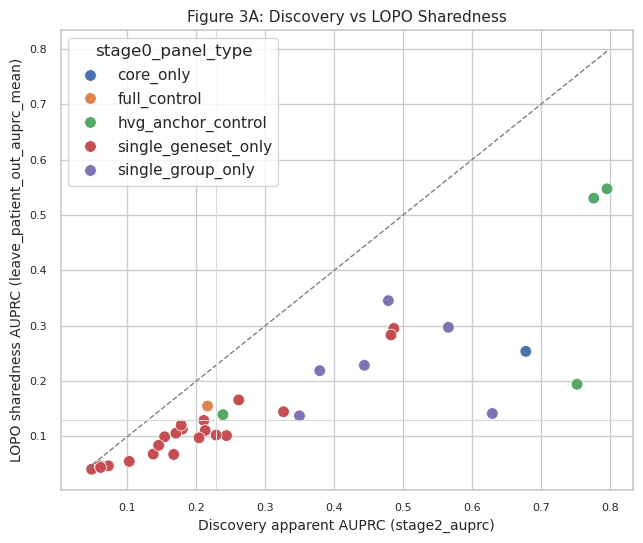

In [ ]:
fig3a_source = plot_discovery_vs_lopo_sharedness(
    discovery_selected,
    lopo_metrics,
    x_metric='stage2_auprc',
    color_by='stage0_panel_type',
    label_top_n=0,
    label_include_patterns=None,
    output_path=OUTPUT_DIR / 'fig3A_discovery_vs_lopo_sharedness.png',
)
fig3a_path = TABLE_DIR / 'fig3A_discovery_vs_lopo_sharedness_source.csv'
fig3a_source.to_csv(fig3a_path, index=False)
print(f'Wrote {fig3a_path} with {len(fig3a_source)} rows')

display(fig3a_source.sort_values('lopo_plot_metric', ascending=False).head(12)[[
    'stage0_panel_id', 'short_panel_label', 'stage0_panel_type', 'stage1_method', 'effective_k',
    'discovery_plot_metric', 'lopo_plot_metric', 'discovery_minus_lopo', 'lopo_join_strategy'
]])

## Part 7: Figure 3B - LOPO Per-Patient Heatmap

LOPO means can hide patient heterogeneity. The heatmap shows which heldout patients transfer well for the selected Stage 0/1 representations. Low malignant count patients are flagged with `*`; normal-only patients are marked `N` and should be interpreted via specificity or false-positive burden rather than AUROC/AUPRC.


Wrote Fig 3B matrix and patient support tables


heldout_patient_id,P01,P02,P03,P04,P05,P06,P07,P09,P13
heatmap_row_label,,,,,,,,,
1000,0.035232,0.543442,0.980407,0.275139,0.170811,0.050086,0.035975,0.212104,0.008474
10000,0.014676,0.751334,0.603571,0.415889,0.012682,0.024155,0.023821,0.084934,0.004043
3000,0.037945,0.634113,0.985518,0.260977,0.085495,0.027022,0.033908,0.256345,0.011544
500,0.037667,0.430500,0.599147,0.238180,0.225262,0.015864,0.046320,0.190696,0.006863
allograft rejection,0.006132,0.483248,0.805943,0.189610,0.009893,0.041543,0.118615,0.103400,0.001366


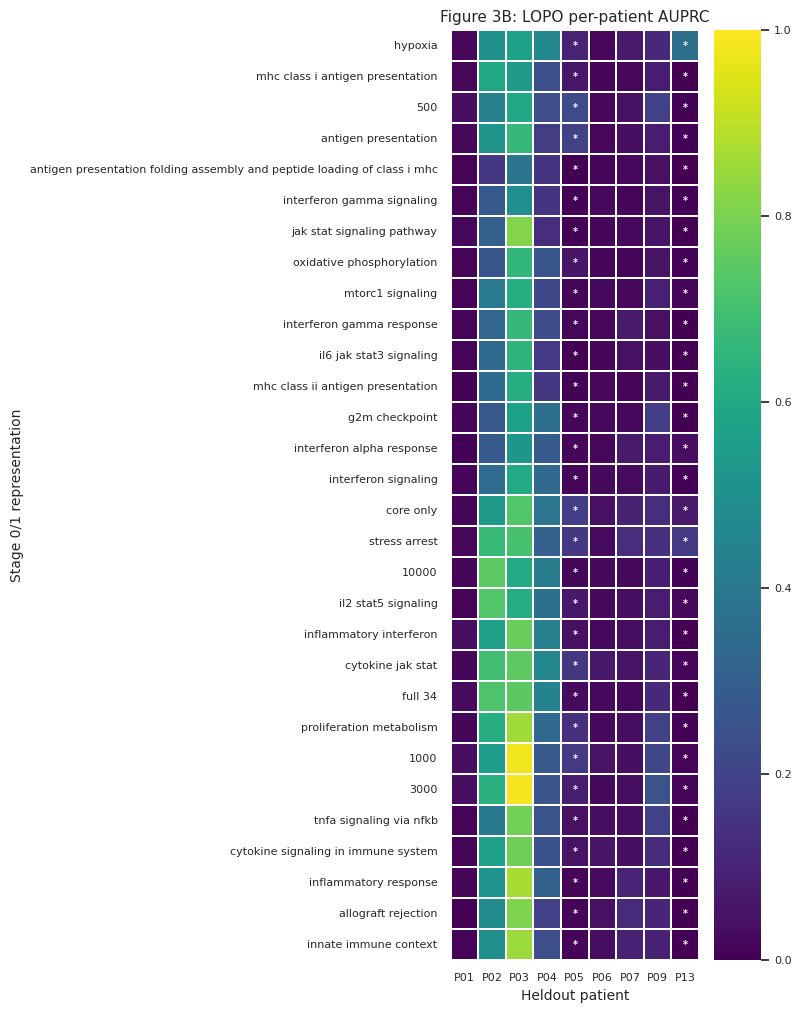

In [9]:
selected_for_heatmap = fig3a_source.sort_values('lopo_plot_metric', ascending=False).head(30) if not fig3a_source.empty else discovery_selected
fig3b_long = plot_lopo_patient_heatmap(
    lopo_by_patient,
    selected_for_heatmap,
    output_path=OUTPUT_DIR / 'fig3B_lopo_per_patient_auprc_heatmap.png',
)

if not fig3b_long.empty:
    matrix = fig3b_long.pivot_table(index='heatmap_row_label', columns='heldout_patient_id', values='heatmap_value', aggfunc='mean')
    matrix.to_csv(TABLE_DIR / 'fig3B_lopo_per_patient_matrix.csv')
    support_cols = [c for c in [
        'representation_id', 'stage0_panel_id', 'short_panel_label', 'heldout_patient_id',
        'n_test_malignant', 'n_test_non_malignant', 'low_malignant_support', 'normal_only',
        'malignant_prevalence', 'auprc_enrichment', 'stage2_auroc', 'stage2_auprc'
    ] if c in fig3b_long.columns]
    fig3b_long[support_cols].drop_duplicates().to_csv(TABLE_DIR / 'fig3B_lopo_patient_support.csv', index=False)
    print('Wrote Fig 3B matrix and patient support tables')
    display(matrix.head())
else:
    print('Fig 3B was skipped because LOPO by-patient metrics were unavailable.')


## Part 8 and 11: Select Representations for Coefficient Heatmaps

Coefficient heatmaps are intentionally limited to a small set: top high-discovery/high-LOPO representations, high-discovery/low-LOPO gaps, immune panels of special interest, and controls.


In [10]:
coef_rep_selection = select_representations_for_coefficient_heatmaps(
    fig3a_source,
    n_top_shared=N_TOP_SHARED,
    n_top_patient_specific_gap=N_TOP_PATIENT_SPECIFIC_GAP,
    force_include_patterns=N_FORCE_INCLUDE_PATTERNS,
)
coef_rep_path = TABLE_DIR / 'stage2_fig3_selected_representations_for_coefficient_heatmaps.csv'
coef_rep_selection.to_csv(coef_rep_path, index=False)
print(f'Wrote {coef_rep_path} with {len(coef_rep_selection)} rows')
display(coef_rep_selection)

Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/stage2_fig3_selected_representations_for_coefficient_heatmaps.csv with 24 rows


,representation_id,stage0_panel_id,short_panel_label,biological_theme,stage1_method,effective_k,discovery_auprc,lopo_auprc,discovery_minus_lopo,selection_reason
0,hvg_top_requested_3000__available_3000|dr|fa|40|42,hvg_top_requested_3000__available_3000,3000,hvg_control,fa,40,0.796105,0.547471,0.248634,force_include_interest_or_control;high_discovery_low_lopo_gap;top_high_discovery_high_lopo
1,hvg_top_requested_1000__available_1000|dr|factosig_promax|40|42,hvg_top_requested_1000__available_1000,1000,hvg_control,factosig_promax,40,0.776937,0.530612,0.246326,force_include_interest_or_control;top_high_discovery_high_lopo
2,single_group__innate_immune_context|dr|fa|20|42,single_group__innate_immune_context,innate immune context,inflammatory_immune,fa,20,0.478741,0.345406,0.133335,top_high_discovery_high_lopo
3,single_group__proliferation_metabolism|dr|factosig_promax|40|42,single_group__proliferation_metabolism,proliferation metabolism,metabolism,factosig_promax,40,0.565879,0.297266,0.268613,high_discovery_low_lopo_gap;top_high_discovery_high_lopo
4,single_geneset__hallmark_inflammatory_response|dr|fa|20|42,single_geneset__hallmark_inflammatory_response,inflammatory response,inflammatory_immune,fa,20,0.486626,0.295141,0.191485,top_high_discovery_high_lopo
5,hvg_top_requested_500__available_500|dr|fa|40|42,hvg_top_requested_500__available_500,500,hvg_control,fa,40,0.752640,0.194204,0.558436,force_include_interest_or_control;high_discovery_low_lopo_gap
6,single_group__stress_arrest|dr|factosig_promax|40|42,single_group__stress_arrest,stress arrest,hypoxia_stress,factosig_promax,40,0.629652,0.141448,0.488204,high_discovery_low_lopo_gap
7,core_only|dr|pca|40|42,core_only,core only,core_control,pca,40,0.678275,0.253728,0.424547,force_include_interest_or_control;high_discovery_low_lopo_gap
8,full_34|dr|fa|10|42,full_34,full 34,full_control,fa,10,0.216292,0.155008,0.061284,force_include_interest_or_control
9,hvg_top_requested_10000__available_10000|dr|factosig|10|42,hvg_top_requested_10000__available_10000,10000,hvg_control,factosig,10,0.238657,0.139379,0.099278,force_include_interest_or_control


## Part 8: Figure 3C - LOPO Coefficient Stability

This plot compares coefficient stability across LOPO training folds, but only within the same Stage 0/1 representation basis. Stable selected factors across heldout folds support shared program usage. Unstable signs or one-fold-only selection suggest weak or redundant factors.

If LOPO fold coefficients are absent, this section records the caveat and writes an empty summary table rather than failing.


In [11]:
factor_stability_parts = []
fig3c_paths = []
if lopo_coef.empty:
    warnings.warn('LOPO coefficient paths were not found in this completed run; Fig 3C will be skipped.')
else:
    for rid in coef_rep_selection['representation_id'].dropna().astype(str):
        safe_id = safe_filename(rid)
        selected_row = discovery_selected.loc[discovery_selected['representation_id'].astype(str).eq(rid)]
        selected_row = selected_row.iloc[0] if not selected_row.empty else None
        summary = plot_lopo_coefficient_stability(
            lopo_coef,
            rid,
            selected_regularization_row=selected_row,
            output_path=OUTPUT_DIR / f'fig3C_lopo_coef_stability__{safe_id}.png',
        )
        if not summary.empty:
            summary.to_csv(TABLE_DIR / f'fig3C_lopo_coef_stability__{safe_id}__feature_summary.csv', index=False)
            factor_stability_parts.append(summary)
            fig3c_paths.append(OUTPUT_DIR / f'fig3C_lopo_coef_stability__{safe_id}.png')

factor_stability = pd.concat(factor_stability_parts, ignore_index=True) if factor_stability_parts else pd.DataFrame(columns=[
    'representation_id', 'feature_id', 'selection_frequency', 'sign_stability', 'mean_abs_coef',
    'mean_coef', 'n_folds_selected', 'n_folds_total', 'top_loading_genes_if_available'
])
factor_stability_path = TABLE_DIR / 'stage2_fig3_factor_stability_summary.csv'
factor_stability.to_csv(factor_stability_path, index=False)
print(f'Wrote {factor_stability_path} with {len(factor_stability)} rows')


Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/stage2_fig3_factor_stability_summary.csv with 0 rows


/tmp/ipykernel_1787925/2107500833.py:4: UserWarning: LOPO coefficient paths were not found in this completed run; Fig 3C will be skipped.
  warnings.warn('LOPO coefficient paths were not found in this completed run; Fig 3C will be skipped.')


## Part 9: Figure 3D - Discovery vs Patient-Specific Factor Usage

This compares patient-specific factor usage against the discovery/shared model on the same latent basis. Same factors across patients support sharedness. Different factors in individual patients suggest patient-specific biology, while recurrent alternative factors across several patients suggest subgroup programs. Low malignant support patients should be flagged and not overinterpreted.


/home/minhang/mds_project/sc_classification/scripts/comprehensive_run/stage2_sharedness_plotting.py:1128: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = _plt.subplots(figsize=(width, height))


Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/stage2_fig3_patient_overlap_summary.csv with 216 rows


,representation_id,patient_id,jaccard_with_discovery,overlap_count,patient_selected_count,discovery_selected_count,discovery_selection_rule
0,hvg_top_requested_3000__available_3000|dr|fa|40|42,P01,0.666667,26,39,26,coef_nonzero
1,hvg_top_requested_3000__available_3000|dr|fa|40|42,P02,0.650000,26,40,26,coef_nonzero
2,hvg_top_requested_3000__available_3000|dr|fa|40|42,P03,0.600000,21,30,26,coef_nonzero
3,hvg_top_requested_3000__available_3000|dr|fa|40|42,P04,0.650000,26,40,26,coef_nonzero
4,hvg_top_requested_3000__available_3000|dr|fa|40|42,P05,0.648649,24,35,26,coef_nonzero


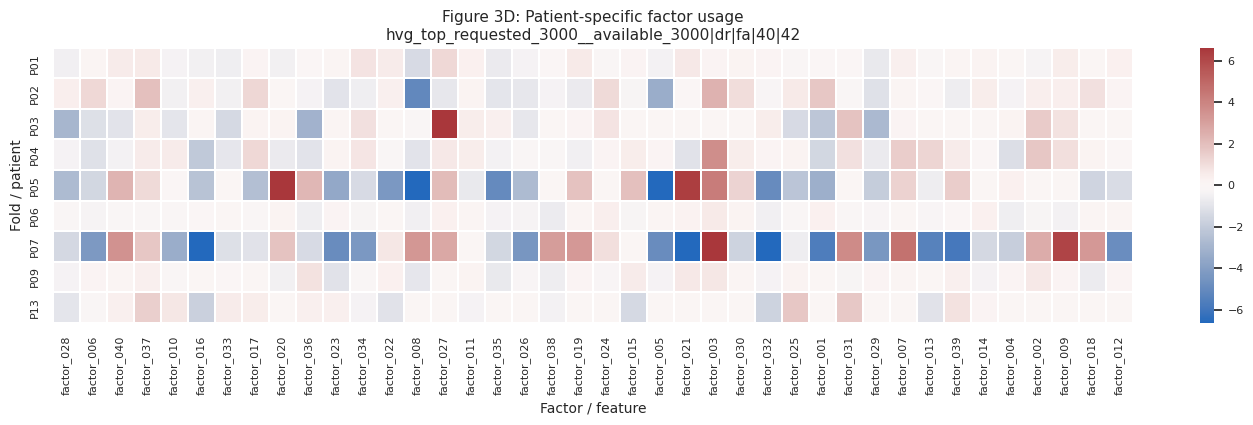

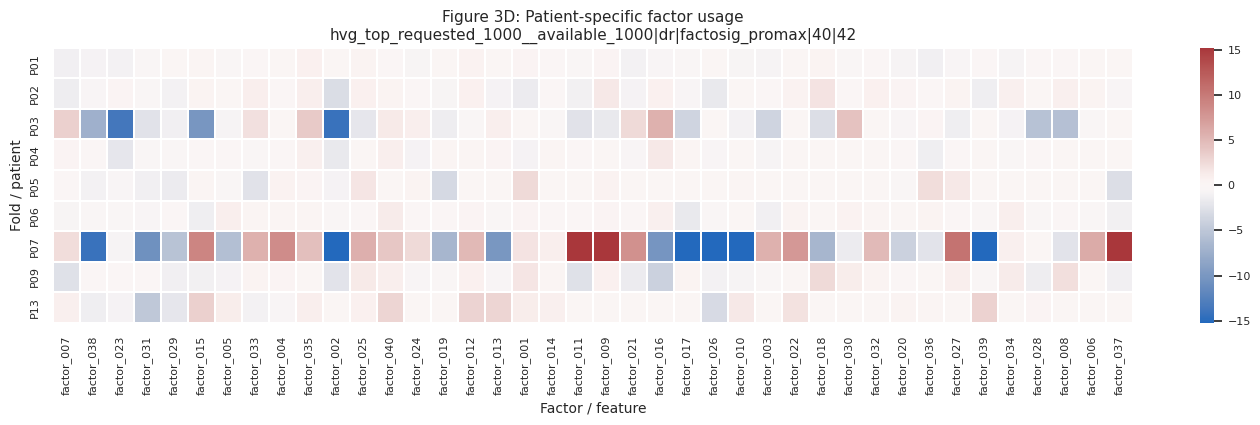

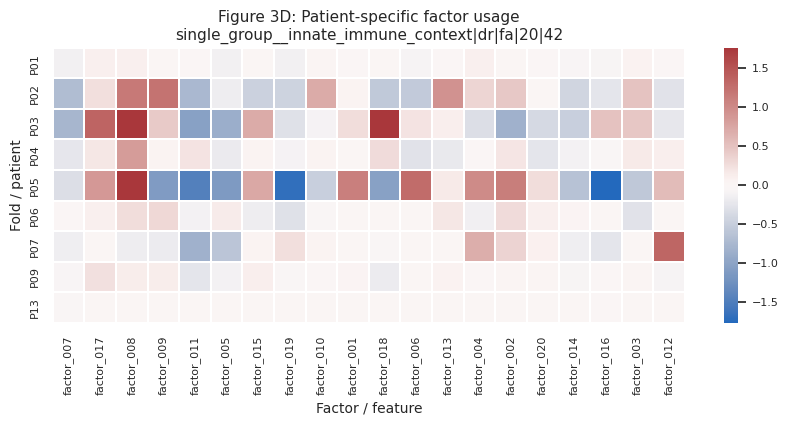

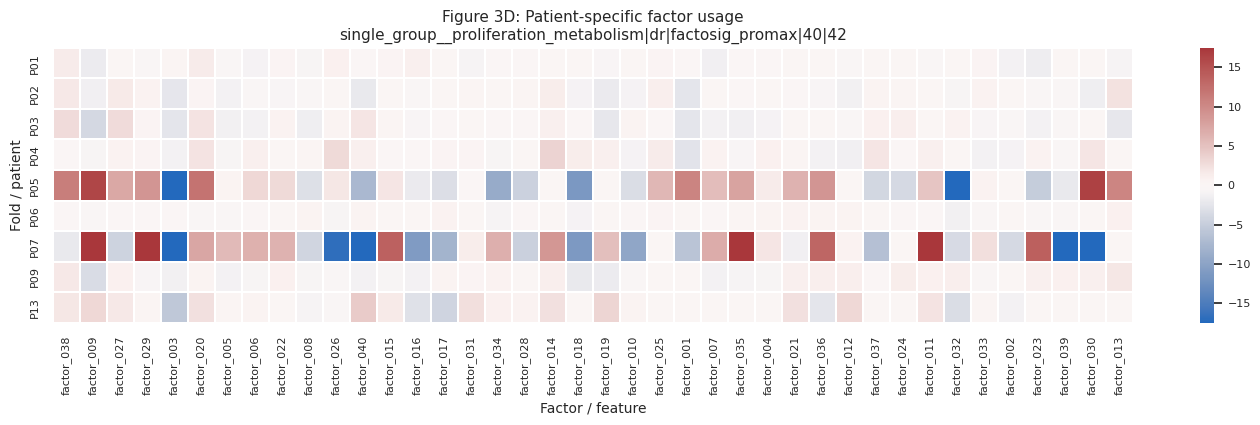

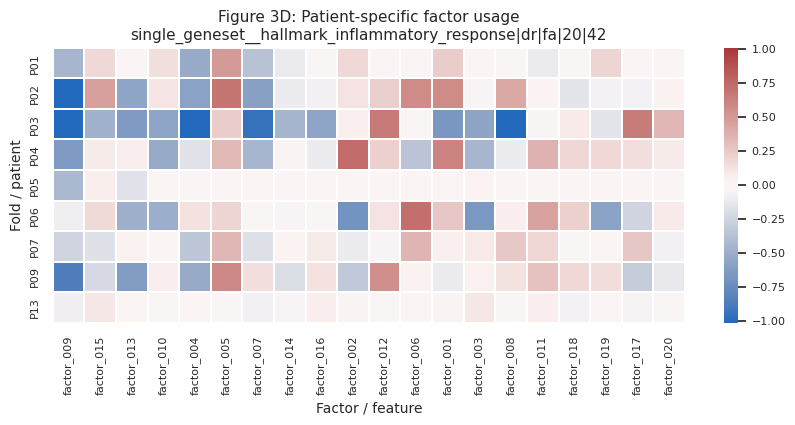

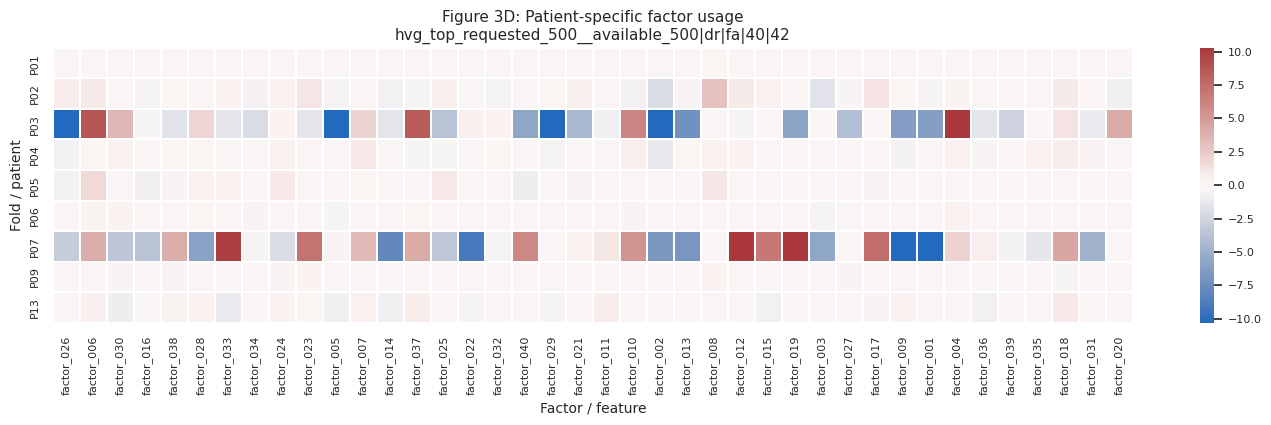

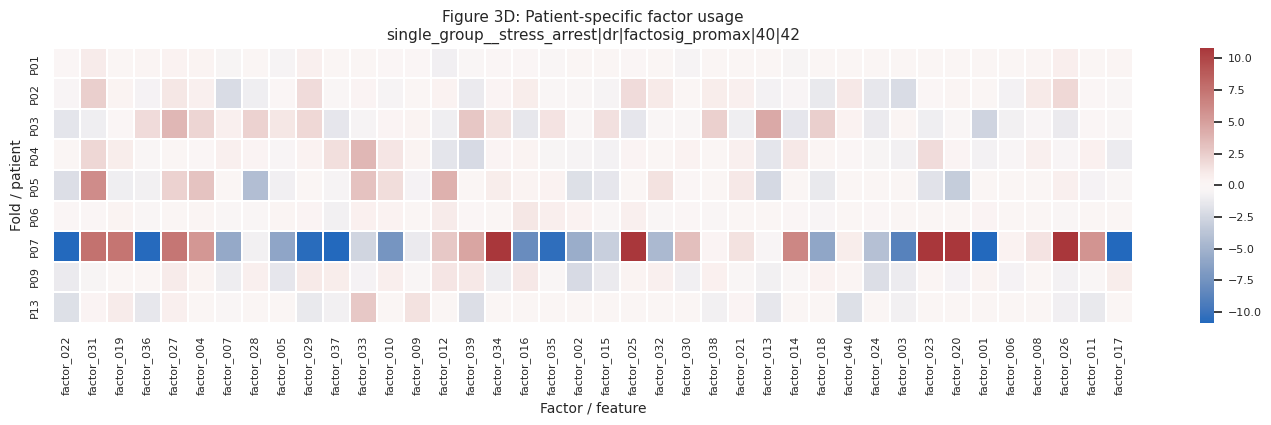

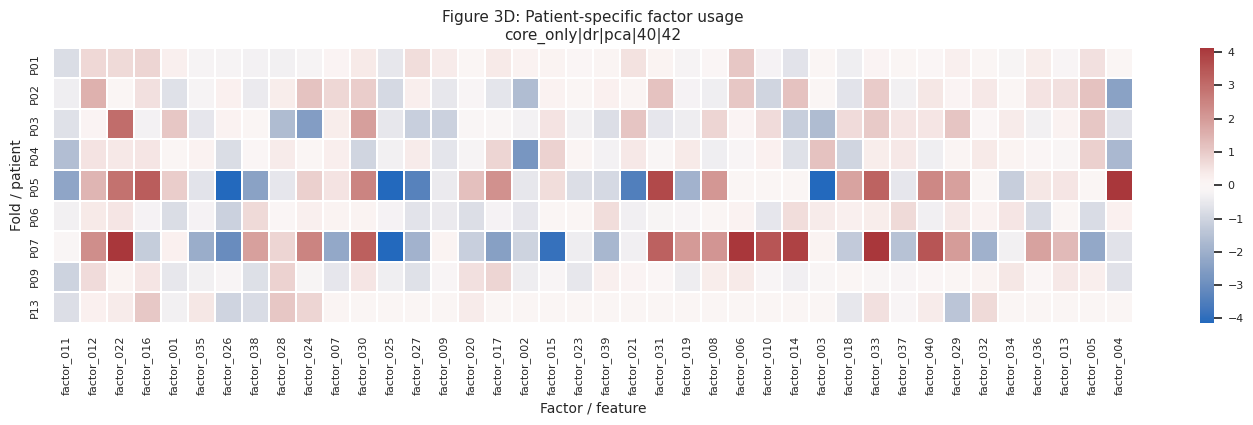

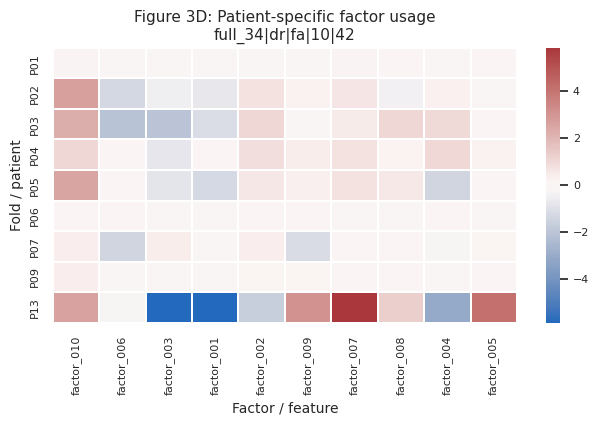

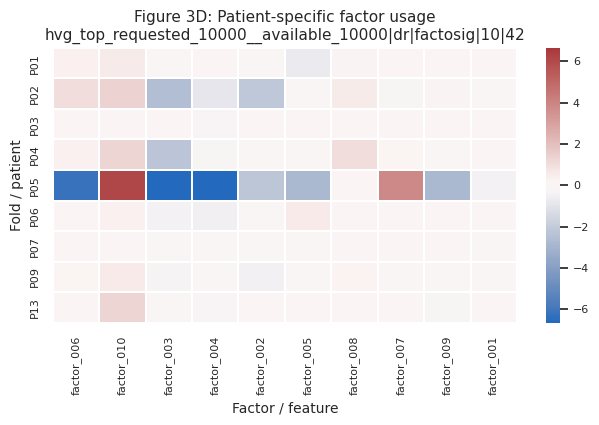

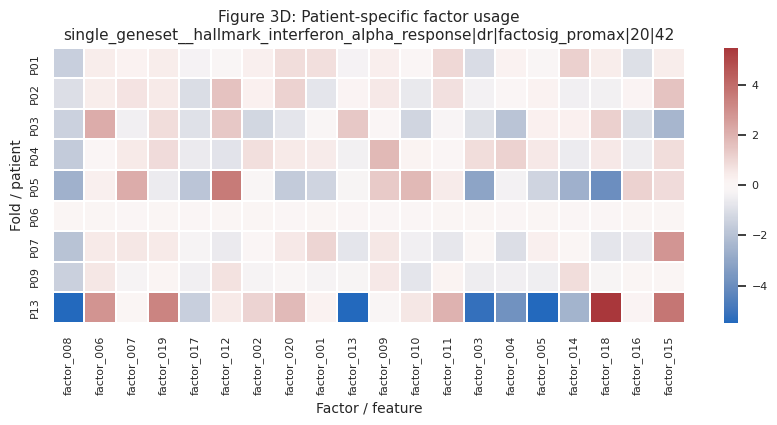

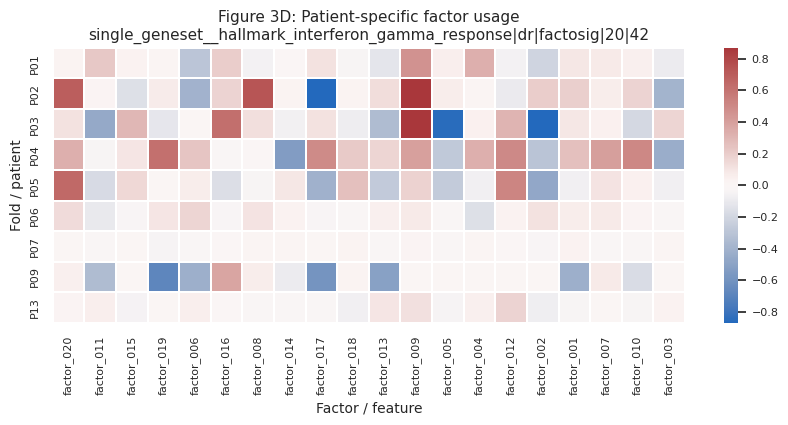

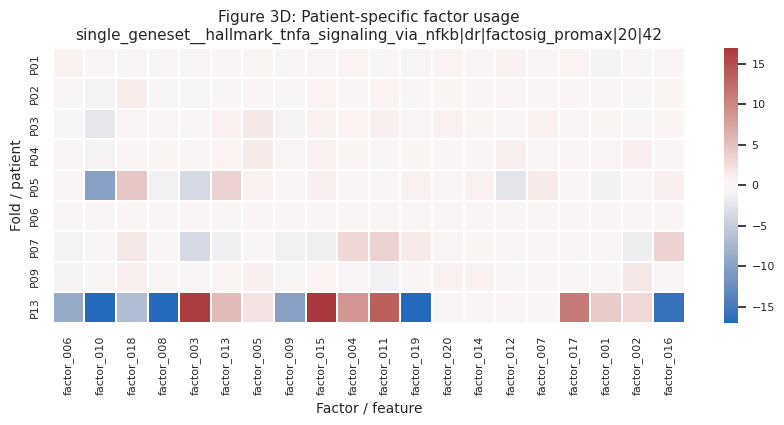

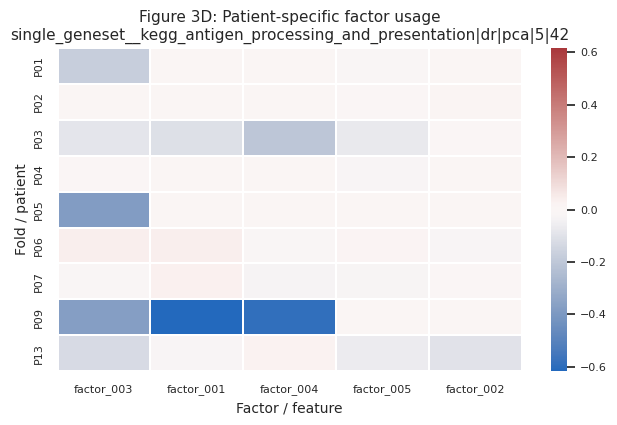

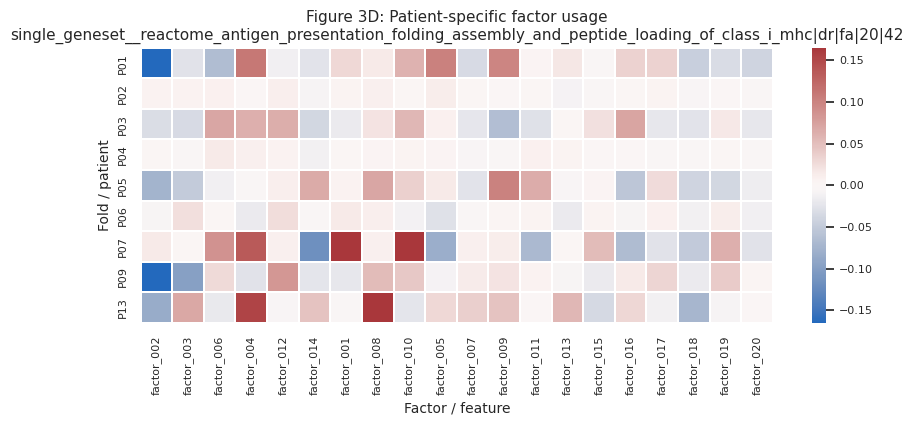

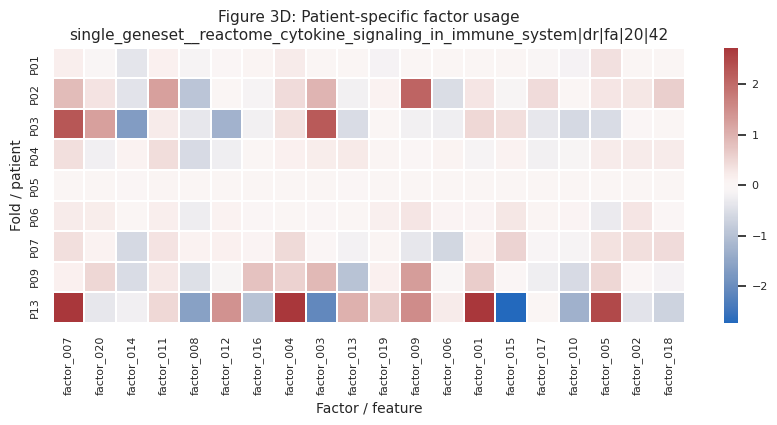

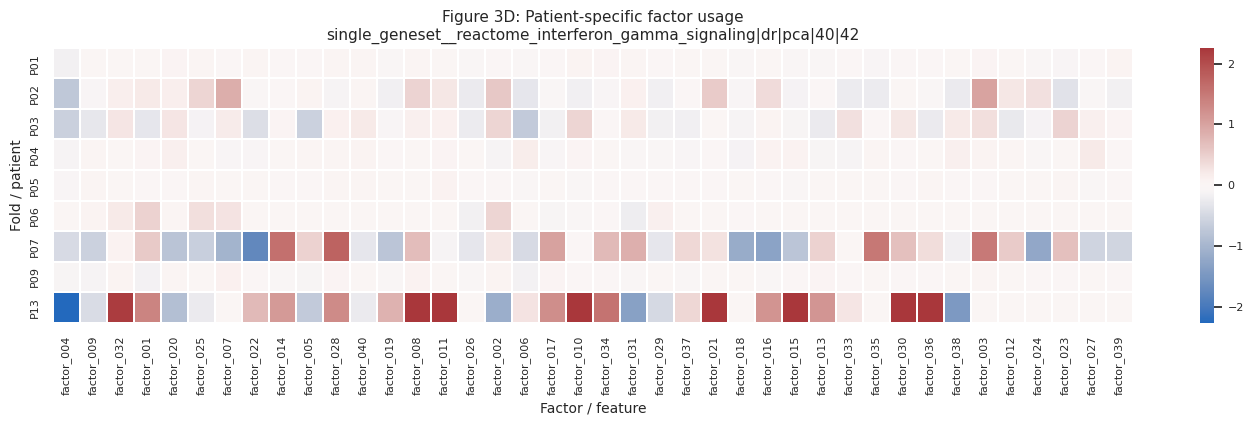

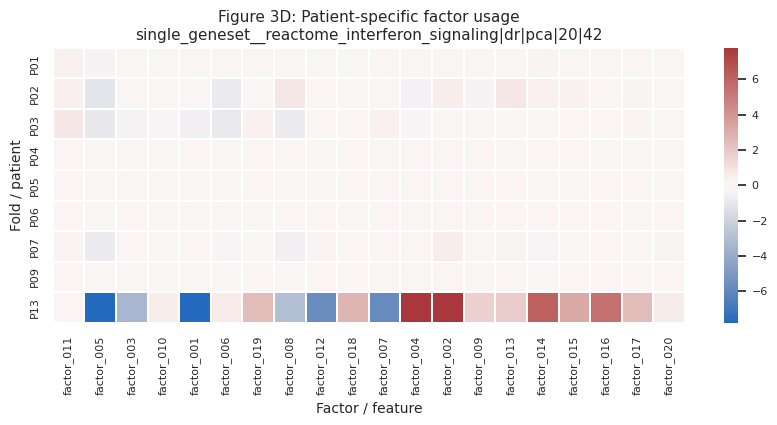

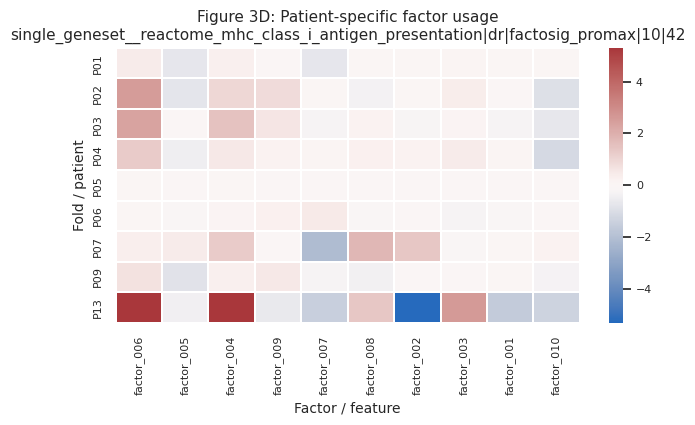

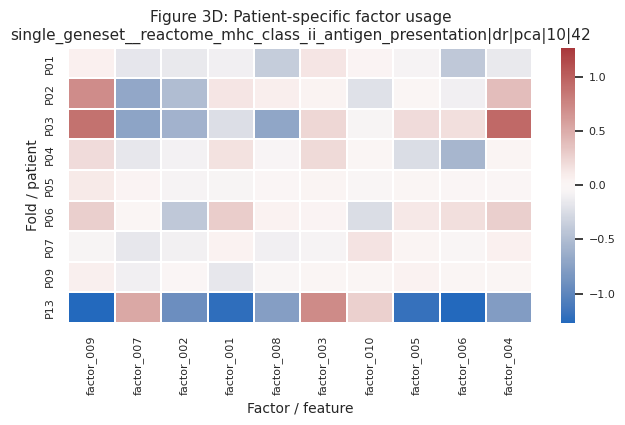

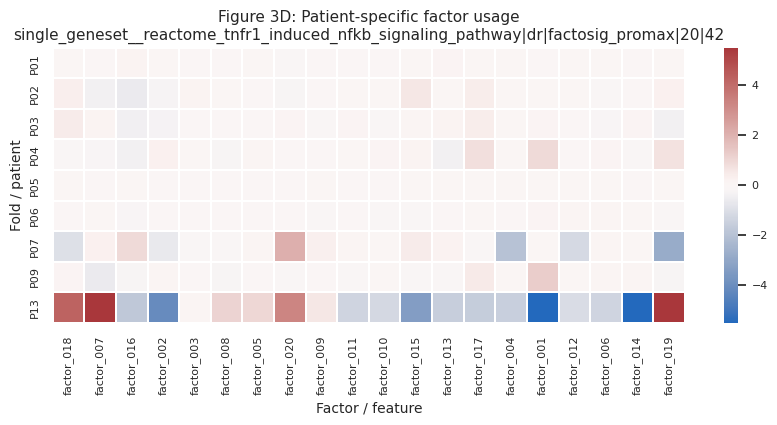

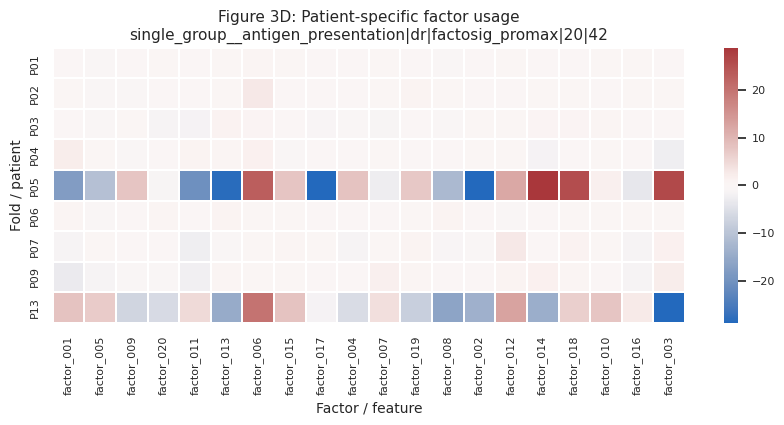

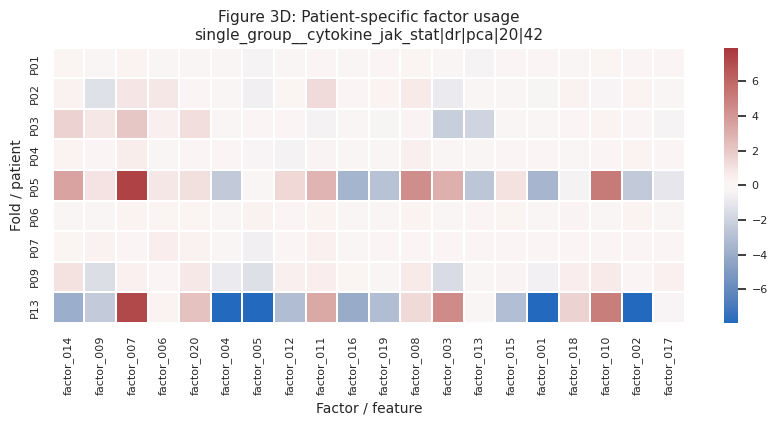

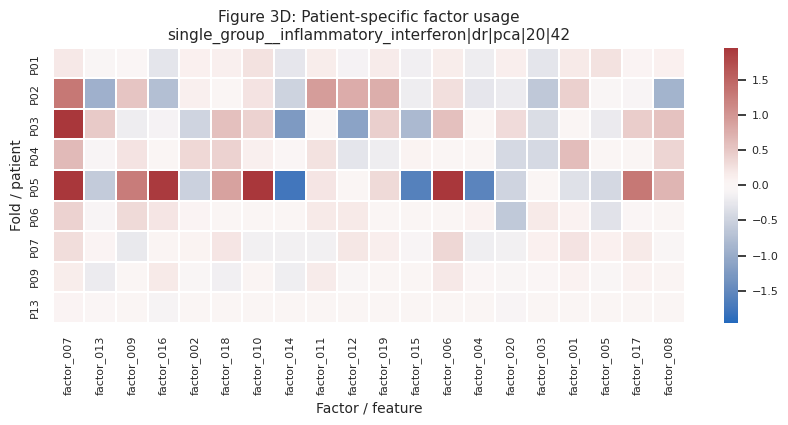

In [12]:
patient_selected = select_regularization_rows(
    patient_specific_metrics,
    group_cols=['representation_id', 'patient_id'],
    metric_col='stage2_auprc',
    mode=SELECTION_MODE,
    penalty_priority=PENALTY_PRIORITY,
    min_nonzero=1,
)
patient_selected.to_csv(TABLE_DIR / 'stage2_fig3_patient_specific_selected_regularization_rows.csv', index=False)

matrix_parts = []
overlap_parts = []
fig3d_paths = []
for rid in coef_rep_selection['representation_id'].dropna().astype(str):
    safe_id = safe_filename(rid)
    discovery_rows = discovery_selected.loc[discovery_selected['representation_id'].astype(str).eq(rid)]
    selected_row = discovery_rows.iloc[0] if not discovery_rows.empty else None
    if selected_row is not None and bool(selected_row.get('flag_dense_solution', False)):
        near_best = choose_interpretable_row_near_best(
            discovery_metrics.loc[discovery_metrics['representation_id'].astype(str).eq(rid)],
            best_metric_col='stage2_auprc',
            tolerance=0.02,
        )
        if not near_best.empty:
            selected_row = near_best
    matrix, overlap = plot_patient_specific_factor_usage(
        patient_specific_coef,
        discovery_coef,
        rid,
        selected_discovery_row=selected_row,
        patient_selected_df=patient_selected,
        output_path=OUTPUT_DIR / f'fig3D_patient_specific_factor_usage__{safe_id}.png',
    )
    if not matrix.empty:
        matrix.to_csv(TABLE_DIR / f'fig3D_patient_specific_factor_usage__{safe_id}__matrix.csv', index=False)
        overlap.to_csv(TABLE_DIR / f'fig3D_patient_specific_factor_usage__{safe_id}__overlap.csv', index=False)
        matrix_parts.append(matrix)
        overlap_parts.append(overlap)
        fig3d_paths.append(OUTPUT_DIR / f'fig3D_patient_specific_factor_usage__{safe_id}.png')

patient_overlap = pd.concat(overlap_parts, ignore_index=True) if overlap_parts else pd.DataFrame()
patient_overlap_path = TABLE_DIR / 'stage2_fig3_patient_overlap_summary.csv'
patient_overlap.to_csv(patient_overlap_path, index=False)
print(f'Wrote {patient_overlap_path} with {len(patient_overlap)} rows')
display(patient_overlap.head())


## Part 13: Final Summary Tables and Report

The final report records artifact sources, selection mode, LOPO metric choice, top shared candidates, high-discovery/low-LOPO candidates, caveats, and figure paths.


In [13]:
summary_table = fig3a_source.copy()
if not summary_table.empty:
    keep_cols = [c for c in [
        'representation_id', 'stage0_panel_id', 'short_panel_label', 'biological_theme', 'stage1_method',
        'effective_k', 'penalty', 'C', 'l1_ratio', 'discovery_plot_metric', 'lopo_plot_metric',
        'discovery_minus_lopo', 'flag_dense_solution', 'lopo_join_strategy'
    ] if c in summary_table.columns]
    summary_table = summary_table[keep_cols]
summary_table_path = TABLE_DIR / 'stage2_fig3_summary_table.csv'
summary_table.to_csv(summary_table_path, index=False)

figure_paths = [
    OUTPUT_DIR / 'fig3A_discovery_vs_lopo_sharedness.png',
    OUTPUT_DIR / 'fig3A_discovery_vs_lopo_sharedness.pdf',
    OUTPUT_DIR / 'fig3B_lopo_per_patient_auprc_heatmap.png',
    OUTPUT_DIR / 'fig3B_lopo_per_patient_auprc_heatmap.pdf',
    *fig3c_paths,
    *fig3d_paths,
]
figure_paths = [p for p in figure_paths if p.exists() or p.suffix in {'.png', '.pdf'}]

missing_caveats = []
if lopo_coef.empty:
    missing_caveats.append('LOPO fold coefficient paths were not found, so Fig 3C coefficient stability is skipped until those coefficients are generated.')
if discovery_selected.get('flag_dense_solution', pd.Series(dtype=bool)).any():
    missing_caveats.append('Some max-AUPRC discovery rows are dense; coefficient heatmaps use near-best sparse rows when available or top absolute coefficients for L2.')

lopo_metric_used = 'lopo_plot_metric'
report_path = TABLE_DIR / 'stage2_fig3_sharedness_visualization_report.md'
write_markdown_report(
    report_path,
    artifact_inventory=inventory,
    selection_mode=SELECTION_MODE,
    lopo_metric=lopo_metric_used,
    fig3a_source=fig3a_source,
    selected_representations=coef_rep_selection,
    missing_caveats=missing_caveats,
    figure_paths=figure_paths,
)
print(f'Wrote {summary_table_path}')
print(f'Wrote {report_path}')


Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/stage2_fig3_summary_table.csv
Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness/stage2_fig3_sharedness_visualization_report.md
